In [ ]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [2]:
# import
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 데이터 셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.model_selection import train_test_split # 데이터 분할(층화추출로)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib import pyplot as plt # 학습과정 loss와 acc 시각화
# quiz에서는 scale조정, train_test_split 등을 추가

In [3]:
# 1. 데이터 셋
width = 28; height = 28
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [1]:
# 코랩에서 한글 그래프 적용하려면(세션 다시 시작)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

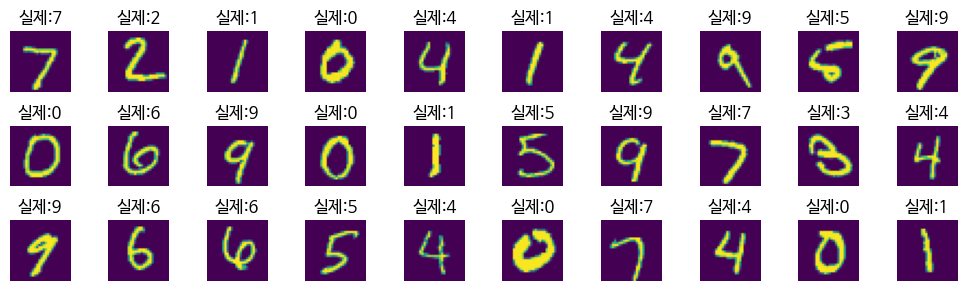

In [4]:
plt_row = 3
plt_col = 10
# plt.figure(figsize=(plt_col, plt_row))
plt.rcParams['figure.figsize'] = [plt_col, plt_row]
# plt.rc('font', family='Malgun Gothic') # window에서 한글 시각화
plt.rc('font', family='NanumBarunGothic') # 코랩에서 한글 시각화
fig, axes = plt.subplots(plt_row, plt_col)
# axes[0, 0].imshow(X_test[0].reshape(width, height))
# axes[0, 0].axis('off')
# title = '실제:{}'.format(y_test[0])
# axes[0, 0].set_title(title)
# plt.subplot_adjust(hspace=0.4, wspace=0.3)
for i in range(plt_row*plt_col):
    subax = axes[i//plt_col, i%plt_col] # // 몫연산자, % 나머지연산자
    subax.imshow(X_test[i].reshape(width, height))
    subax.axis('off')
    title = '실제:{}'.format(y_test[i])
    subax.set_title(title)
plt.tight_layout()

# 1. DNN

In [4]:
%%time
# 1. 데이터 생성 및 전처리
width = 28; height = 28
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_val = X_train[50000:]; y_val = y_train[50000:]
X_train = X_train[:50000]; y_train = y_train[:50000]
# 독립변수 (28,28) => 784 1차원 -> 실수형변환 -> 스케일조정
X_train = X_train.reshape(-1, width*height).astype('float32')/255.0
X_val   = X_val.reshape(-1, width*height).astype('float32')/255.0
X_test = X_test.reshape(-1, width*height).astype('float32')/255.0
# 타겟변수 원핫인코딩
Y_train = to_categorical(y_train)
Y_val   = to_categorical(y_val)
Y_test  = to_categorical(y_test)
X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape

# 2.모델 구성
model = Sequential([
    Input(shape=(width*height,)),
    Dense(units=1024, activation='relu'),
    Dropout(0.3),
    Dense(units=512, activation='relu'),
    Dropout(0.2),
    Dense(units=256, activation='relu'),
    Dropout(0.1),
    Dense(units=10, activation='softmax')
])
# model.summary()
# 3. 학습 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])
# 4. 학습

hist = model.fit(X_train, Y_train,
                epochs=50,
                validation_data=(X_val, Y_val),
                verbose=1) # 콜백함수

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8733 - loss: 0.4018 - val_accuracy: 0.9661 - val_loss: 0.1244
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9582 - loss: 0.1379 - val_accuracy: 0.9725 - val_loss: 0.0962
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9677 - loss: 0.1082 - val_accuracy: 0.9770 - val_loss: 0.0837
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9743 - loss: 0.0845 - val_accuracy: 0.9772 - val_loss: 0.0807
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9779 - loss: 0.0741 - val_accuracy: 0.9790 - val_loss: 0.0737
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9812 - loss: 0.0652 - val_accuracy: 0.9717 - val_loss: 0.1045
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9808 - loss: 0.0624 - val_accuracy: 0.9772 - val_loss: 0.0962
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━

In [ ]:
model.save('minst_dnn.h5')

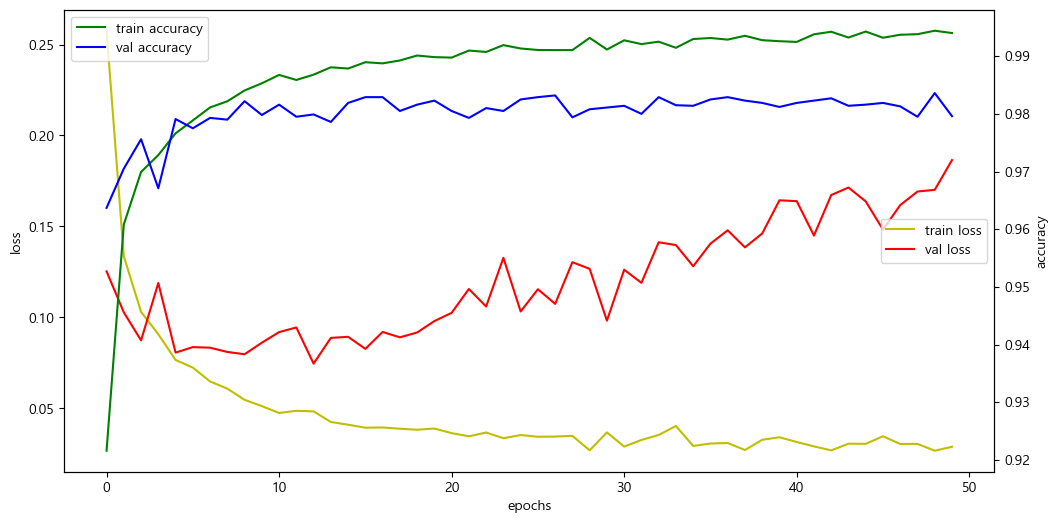

In [ ]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [ ]:
model.evaluate(X_test, Y_test)

313/313 [==============================] - 1s 5ms/step - loss: 0.1894 - accuracy: 0.9826


[0.1894107609987259, 0.9825999736785889]

In [ ]:
# 혼동행렬
from sklearn.metrics import confusion_matrix
print('실제값 : ', y_test)
print('실제값 : ', np.argmax(Y_test, axis=1))
y_hat = model.predict(X_test).argmax(axis=1)
cmatrix = confusion_matrix(y_test, y_hat)
cmatrix

실제값 :  [7 2 1 ... 4 5 6]
실제값 :  [7 2 1 ... 4 5 6]
313/313 [==============================] - 1s 4ms/step


array([[ 972,    1,    0,    0,    0,    1,    3,    1,    2,    0],
       [   0, 1123,    1,    0,    0,    2,    3,    0,    6,    0],
       [   0,    1, 1020,    1,    1,    0,    1,    4,    4,    0],
       [   0,    0,    3, 1000,    0,    2,    0,    4,    1,    0],
       [   1,    1,    3,    0,  956,    0,    6,    2,    0,   13],
       [   3,    0,    0,   11,    1,  866,    6,    1,    3,    1],
       [   2,    2,    0,    0,    2,    2,  950,    0,    0,    0],
       [   1,    5,   11,    3,    1,    0,    0, 1001,    3,    3],
       [   0,    0,    3,    4,    3,    1,    1,    3,  957,    2],
       [   1,    3,    0,    4,    7,    3,    0,    4,    6,  981]],
      dtype=int64)

In [ ]:
# 실제값과 예측값이 다른 갯수(방법1)
cnt = 0
for i, row in enumerate(cmatrix):
    for j, data in enumerate(row):
        if i!=j:
            cnt+=data
print('예측이 틀린 갯수 :', cnt)

예측이 틀린 갯수 : 174


In [ ]:
# 실제값과 예측값이 다른 갯수(방법1)
cnt = 0
for y, h in zip(y_test, y_hat):
    if y!=h:
        cnt +=1
print('예측이 틀린 갯수 :', cnt)

예측이 틀린 갯수 : 174


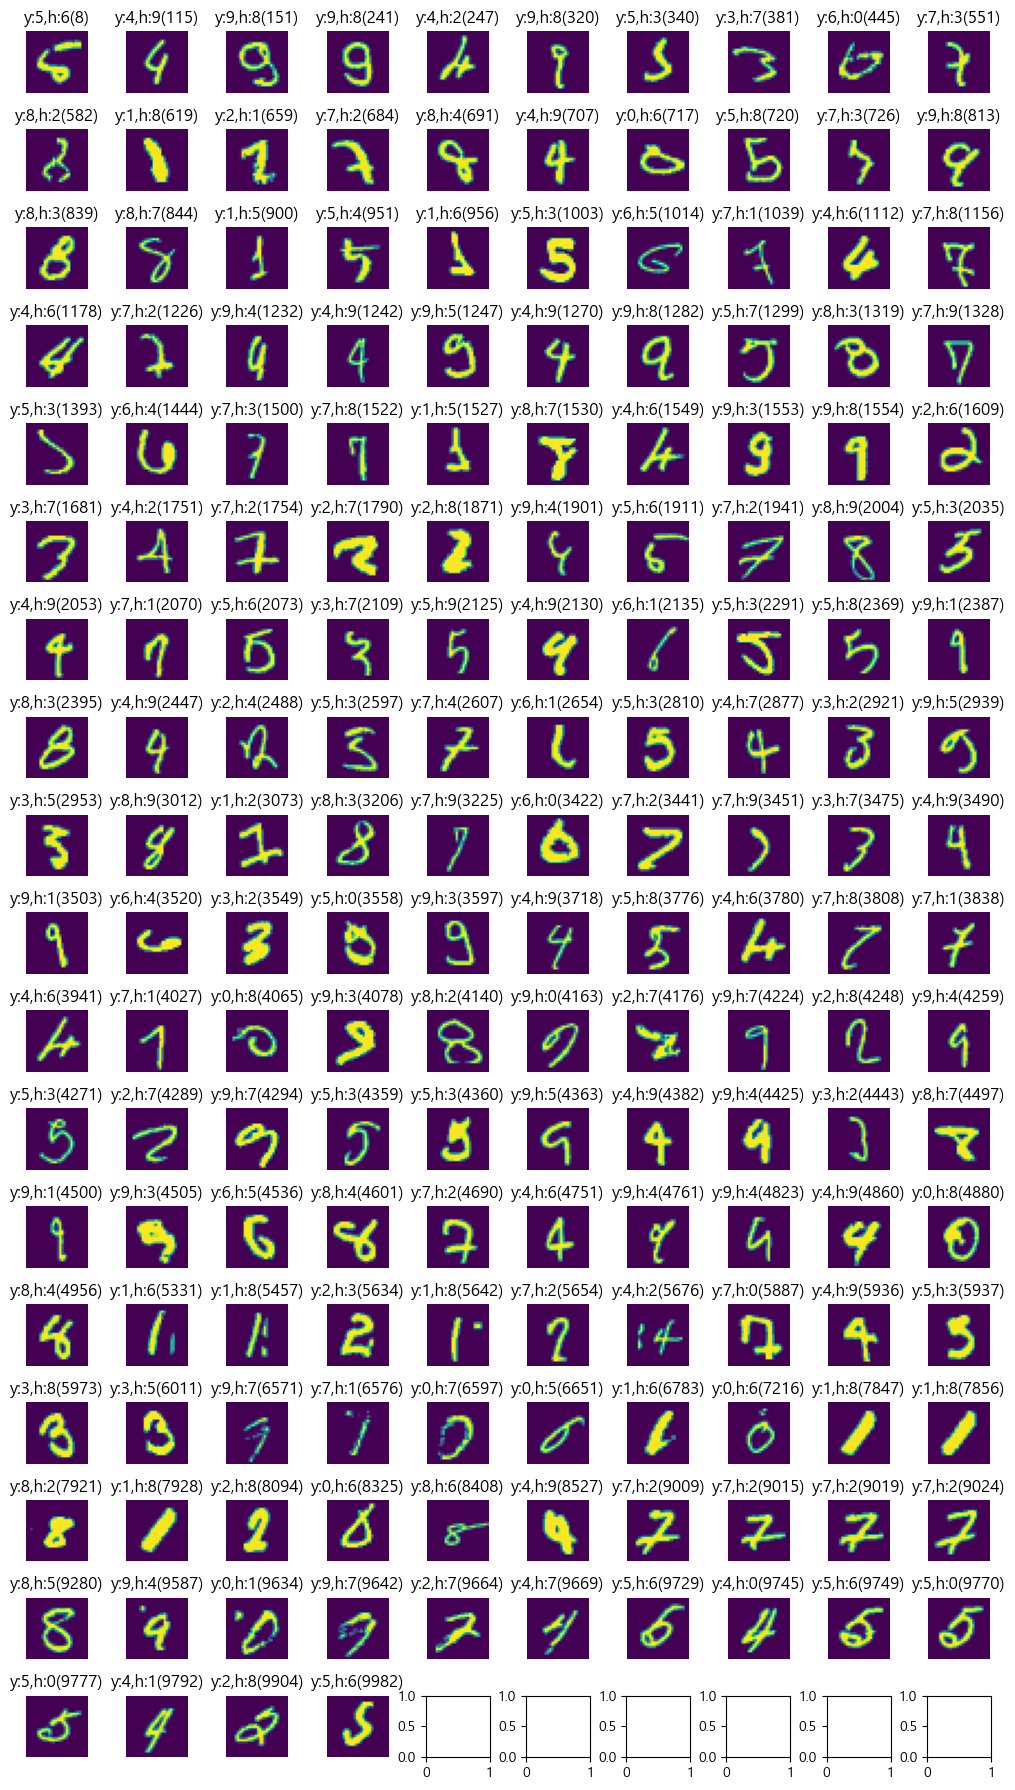

In [ ]:
# CNN을 사용하여 예측이 틀린 데이터 출력(y_hat과 y_test가 다른 것들 174개)
plt_row = 18
plt_col = 10
plt.rcParams['figure.figsize'] = [plt_col, plt_row]
plt.rc('font', family='Malgun Gothic') # window에서 한글 시각화
# plt.rc('font', family='NanumBarunGothic') # 코랩에서 한글 시각화
fig, axes = plt.subplots(plt_row, plt_col)
plt.subplots_adjust(hspace=0.5, wspace=0.5)

i = 0 # y_hat과 y_test의 index => y_hat[i], y_test[i]를 비교
cnt = 0 # 이미지 출력 횟수
while (i<len(y_test)) & (cnt < plt_row*plt_col):
    if y_hat[i] == y_test[i]:
        i += 1
        continue

    subax = axes[cnt//plt_col, cnt%plt_col] # // 몫연산자, % 나머지연산자
    subax.imshow(X_test[i].reshape(width, height))
    subax.axis('off')
    title = 'y:{},h:{}({})'.format(y_test[i], y_hat[i], i)
    subax.set_title(title)
    cnt += 1 # 이미지 출력번호 증가
    i += 1 # index 증가
plt.tight_layout()

# CNN(컨볼루션 레이어 포함) - 교안 33page

In [6]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten,  Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [11]:
%%time
# 1. 데이터 생성 및 전처리
width = 28; height = 28
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_val = X_train[50000:]; y_val = y_train[50000:]
X_train = X_train[:50000]; y_train = y_train[:50000]
# 독립변수 (28,28) => 784 1차원 -> 실수형변환 -> 스케일조정
X_train = X_train.reshape(-1, width, height).astype('float32')/255.0
X_val   = X_val.reshape(-1, width, height).astype('float32')/255.0
X_test = X_test.reshape(-1, width, height).astype('float32')/255.0
# 타겟변수 원핫인코딩
Y_train = to_categorical(y_train)
Y_val   = to_categorical(y_val)
Y_test  = to_categorical(y_test)
X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape

CPU times: user 320 ms, sys: 75.4 ms, total: 395 ms
Wall time: 394 ms


((50000, 28, 28),
 (50000, 10),
 (10000, 28, 28),
 (10000, 10),
 (10000, 28, 28),
 (10000, 10))

In [12]:
# 2. 모델 생성
model = Sequential()
model.add(Conv2D(filters=32, # 필터수
                 kernel_size=(3,3), # 필터사이즈 (3,3)
                 padding='same', # zero-padding을 하면 출력사이즈도 동일
                 input_shape=(width, height, 1), # 입력채널 1개, 필터 32 => 출력특성맵
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2))) # => 14*14*32
model.add(Dropout(0.1))
model.add(Conv2D(filters=64,
                 kernel_size=(3,3),
                 activation='relu')) # => ((14-3+1)*(14-3+1) * 32) * 64
model.add(MaxPooling2D(pool_size=(2,2))) # => 6*6*32*64
model.add(Dropout(0.25))
model.add(Flatten()) # 입력을 1차원으로
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=10, activation='softmax'))
model.summary()
# 320 <= (3x3 필터가 weight 9 + bias 1) * 32개 필터
# 18,496 <= (3x3 필터가 weight 3*3*32+ bias 1) * 64개 필터

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,146 (1.20 MB)

 Trainable params: 315,146 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
%%time
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
earlyStopping = EarlyStopping(patience=20)
hist = model.fit(X_train, Y_train,
                epochs=50,
                validation_data=(X_val, Y_val),
                verbose=1)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.8361 - loss: 0.4995 - val_accuracy: 0.9860 - val_loss: 0.0529
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9697 - loss: 0.0996 - val_accuracy: 0.9880 - val_loss: 0.0422
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9780 - loss: 0.0732 - val_accuracy: 0.9908 - val_loss: 0.0369
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9821 - loss: 0.0607 - val_accuracy: 0.9918 - val_loss: 0.0329
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9842 - loss: 0.0522 - val_accuracy: 0.9908 - val_loss: 0.0316
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9857 - loss: 0.0445 - val_accuracy: 0.9920 - val_loss: 0.0306
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9869 - loss: 0.0426 - val_accuracy: 0.9930 - val_loss: 0.0311
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9883 - loss: 0.038

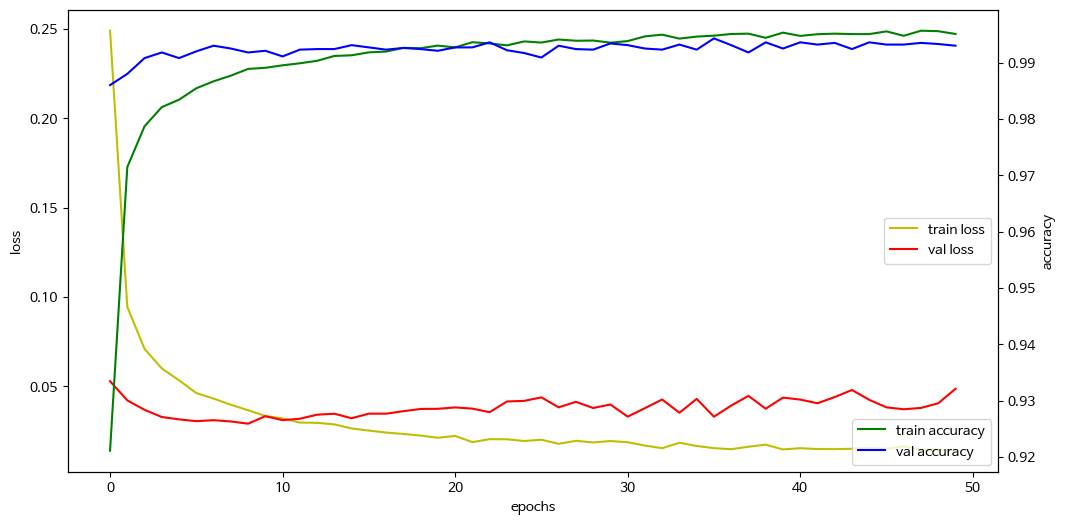

In [14]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [15]:
model.evaluate(X_test, Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9911 - loss: 0.0380


[0.03197316452860832, 0.9933000206947327]

In [16]:
# 혼동행렬
print('실제값 : ', y_test)
print('실제값 : ', np.argmax(Y_test, axis=1))
y_hat = model.predict(X_test).argmax(axis=1)
print('예측값 :', y_hat)
cmatrix = confusion_matrix(y_test, y_hat)
print(cmatrix)

# 실제값과 예측값이 다른 갯수(방법1)
cnt = 0
for y, h in zip(y_test, y_hat):
    if y!=h:
        cnt +=1
print('예측이 틀린 갯수 :', cnt)



실제값 :  [7 2 1 ... 4 5 6]
실제값 :  [7 2 1 ... 4 5 6]
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
예측값 : [7 2 1 ... 4 5 6]
[[ 977    0    0    0    0    0    2    1    0    0]
 [   0 1132    1    1    0    0    0    1    0    0]
 [   1    1 1028    0    0    0    0    2    0    0]
 [   0    0    1 1007    0    1    0    0    1    0]
 [   0    0    0    0  973    0    1    0    1    7]
 [   0    0    0    6    0  884    2    0    0    0]
 [   2    1    0    0    2    4  948    0    1    0]
 [   0    2    5    0    0    0    0 1019    1    1]
 [   1    0    1    0    0    1    0    0  970    1]
 [   0    0    0    0    5    4    0    4    1  995]]
예측이 틀린 갯수 : 67


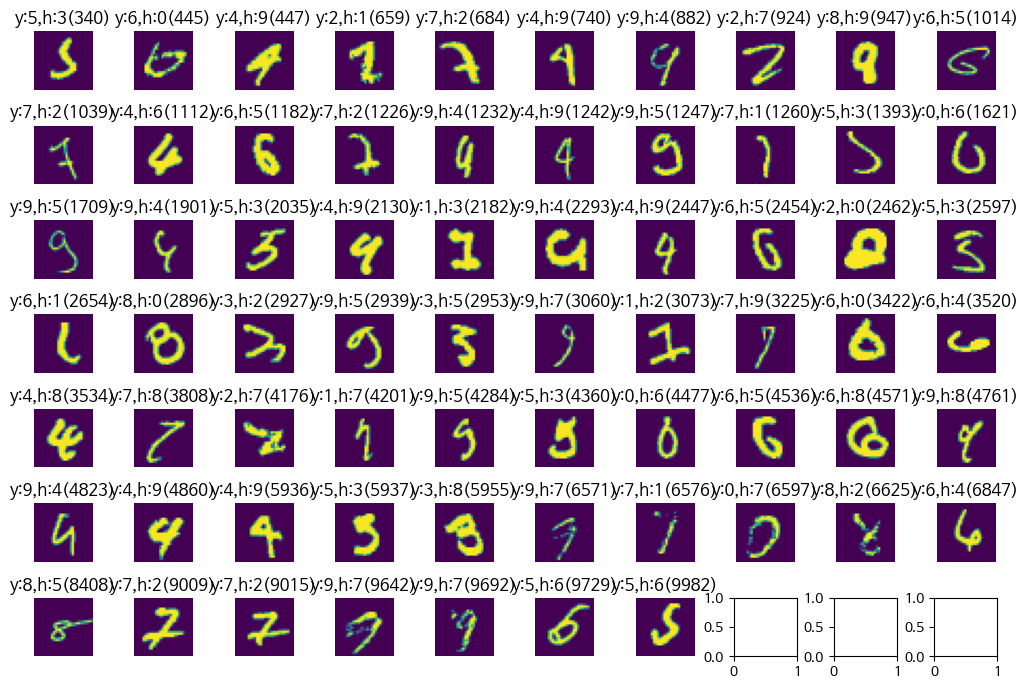

In [18]:
# CNN을 사용하여 예측이 틀린 데이터 출력(y_hat과 y_test가 다른 것들 174개)
plt_row = 7
plt_col = 10
plt.rcParams['figure.figsize'] = [plt_col, plt_row]
# plt.rc('font', family='Malgun Gothic') # window에서 한글 시각화
plt.rc('font', family='NanumBarunGothic') # 코랩에서 한글 시각화
fig, axes = plt.subplots(plt_row, plt_col)
plt.subplots_adjust(hspace=0.5, wspace=0.5)

i = 0 # y_hat과 y_test의 index => y_hat[i], y_test[i]를 비교
cnt = 0 # 이미지 출력 횟수
while (i<len(y_test)) & (cnt < plt_row*plt_col):
    if y_hat[i] == y_test[i]:
        i += 1
        continue

    subax = axes[cnt//plt_col, cnt%plt_col] # // 몫연산자, % 나머지연산자
    subax.imshow(X_test[i].reshape(width, height))
    subax.axis('off')
    title = 'y:{},h:{}({})'.format(y_test[i], y_hat[i], i)
    subax.set_title(title)
    cnt += 1 # 이미지 출력번호 증가
    i += 1 # index 증가
plt.tight_layout()

In [22]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [23]:
model.save('/content/drive/MyDrive/MBC아카데미/model/mnist.h5')